#   PERCOBAAN 1
remove background, resize dan grayscale

In [ ]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rembg import remove
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

Kode di atas merupakan kumpulan library Python yang digunakan untuk membangun sistem pengolahan citra digital dan klasifikasi data berbasis machine learning. Library **OpenCV (cv2)** digunakan untuk membaca, memproses, dan memanipulasi gambar, sedangkan **Matplotlib** berfungsi untuk menampilkan visualisasi gambar maupun grafik. **NumPy** dan **Pandas** digunakan untuk pengolahan data numerik serta manajemen dataset dalam bentuk array dan tabel. Library **rembg** dimanfaatkan untuk menghapus latar belakang (background) pada gambar sehingga objek utama dapat diproses lebih lanjut. Pada tahap ekstraksi fitur, **scikit-image (skimage)** digunakan untuk menghitung fitur tekstur menggunakan metode **Gray Level Co-occurrence Matrix (GLCM)** dan berbagai properti tekstur melalui fungsi `graycoprops`, sementara **SciPy** menyediakan fungsi `entropy` untuk menghitung tingkat keragaman informasi pada citra. Selanjutnya, **Scikit-learn** digunakan untuk proses machine learning, mulai dari pembagian data latih dan data uji (`train_test_split`), seleksi fitur terbaik (`SelectKBest` dan `f_classif`), hingga pembangunan model klasifikasi seperti **Random Forest**, **Support Vector Machine (SVM)**, dan **K-Nearest Neighbor (KNN)**. Selain itu, berbagai metrik evaluasi seperti **akurasi, presisi, recall, F1-score, confusion matrix**, dan **classification report** digunakan untuk mengukur performa model yang telah dilatih. Terakhir, **Seaborn** dan **ConfusionMatrixDisplay** digunakan untuk memvisualisasikan hasil evaluasi sehingga memudahkan analisis performa model klasifikasi.

## Data Loading

In [7]:
data = []
labels = []
file_name = []

dataset_path = "." 

target_folders = ["Brokoli", "Kembang Kol"]

for sub_folder in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, sub_folder)

    # Validasi: Pastikan itu adalah folder DAN termasuk dalam target_folders kita
    if not os.path.isdir(full_path) or sub_folder not in target_folders:
        continue  

    sub_folder_files = os.listdir(full_path)
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join(full_path, filename)
        
        img = cv.imread(img_path)
        if img is not None:
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            img = cv.resize(img, (256, 256))  # Resize ke ukuran tetap
            img = img.astype(np.uint8)

            data.append(img)
            labels.append(sub_folder)
            name = os.path.splitext(filename)[0]
            file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

# Opsional: Cetak jumlah data untuk memastikan loading berhasil
print(f"Total data gambar berhasil dimuat: {len(data)}")
print(f"Distribusi label: {np.unique(labels, return_counts=True)}")

Total data gambar berhasil dimuat: 200
Distribusi label: (array(['Brokoli', 'Kembang Kol'], dtype='<U11'), array([100, 100]))


Kode diatas berfungsi untuk memuat dataset citra dari folder **Brokoli** dan **Kembang Kol**, kemudian melakukan pra-pemrosesan sebelum digunakan dalam proses klasifikasi. Setiap gambar dibaca menggunakan OpenCV, dikonversi menjadi **grayscale**, diubah ukurannya menjadi **256×256 piksel**, dan disimpan ke dalam variabel `data`, sementara nama folder digunakan sebagai **label kelas** yang disimpan pada variabel `labels`. Nama file gambar juga disimpan untuk keperluan identifikasi data. Setelah seluruh gambar diproses, data dan label dikonversi menjadi array NumPy agar lebih mudah diolah, kemudian program menampilkan jumlah total gambar yang berhasil dimuat serta distribusi data pada masing-masing kelas untuk memastikan proses loading dataset berjalan dengan baik.

## Data Preparation

### Difine Preprocessing

In [8]:
def removeBackground(img):
    if img is None:
        return None
        
    img_removed = remove(img) 
    img_removed_rgb = cv.cvtColor(img_removed, cv.COLOR_RGBA2RGB)
    return img_removed_rgb

Fungsi `removeBackground(img)` digunakan untuk menghapus latar belakang (background) dari sebuah citra menggunakan library **rembg**. Fungsi terlebih dahulu memeriksa apakah gambar yang diberikan bernilai `None`; jika iya, fungsi akan mengembalikan `None` untuk menghindari kesalahan proses. Jika gambar valid, fungsi `remove()` digunakan untuk memisahkan objek utama dari latar belakang sehingga menghasilkan gambar dengan kanal alfa (RGBA). Selanjutnya, gambar hasil penghapusan background dikonversi dari format **RGBA** menjadi **RGB** menggunakan `cv.cvtColor()`, lalu dikembalikan sebagai output untuk digunakan pada tahap pengolahan citra berikutnya.


In [9]:
def grayscale(image):
    if len(image.shape) == 2:
        return image
    elif len(image.shape) == 3:
        r, g, b = image[:,:,0], image[:,:,1], image[:,:,2]
        gray_image = 0.299 * r + 0.587 * g + 0.114 * b
        return gray_image.astype(np.uint8)
    else:
        raise ValueError("Input image must be either grayscale or RGB")

Fungsi `grayscale(image)` digunakan untuk mengonversi citra berwarna (RGB) menjadi citra **grayscale**. Jika citra yang diberikan sudah berupa grayscale (memiliki 2 dimensi), fungsi akan langsung mengembalikan citra tersebut tanpa perubahan. Jika citra memiliki 3 dimensi (RGB), fungsi memisahkan kanal merah (R), hijau (G), dan biru (B), kemudian menghitung nilai grayscale menggunakan rumus standar **0,299R + 0,587G + 0,114B**, yang mempertimbangkan sensitivitas mata manusia terhadap masing-masing warna. Hasil konversi kemudian diubah ke tipe data `uint8` dan dikembalikan sebagai output. Jika format citra tidak sesuai (bukan grayscale maupun RGB), fungsi akan menghasilkan pesan kesalahan (`ValueError`).

In [10]:
def resize(image, new_width, new_height):
    old_height, old_width = image.shape[:2]

    resized_image = np.zeros(
        (new_height, new_width),
        dtype=np.uint8
    )

    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)

            resized_image[i, j] = image[y, x]

    return resized_image

Fungsi `resize(image, new_width, new_height)` digunakan untuk mengubah ukuran citra menjadi dimensi yang diinginkan. Proses resizing dilakukan secara manual dengan memetakan setiap piksel pada gambar baru ke posisi piksel yang sesuai pada gambar asli menggunakan metode **nearest neighbor**, kemudian menyimpan hasilnya ke dalam array baru berukuran `new_width × new_height`.


### Preprocessing

Kode dibawah digunakan untuk melakukan **pra-pemrosesan citra** dengan menghapus background, mengonversi gambar ke grayscale, dan mengubah ukurannya menjadi **256×256 piksel** melalui fungsi `percobaan1()`. Selanjutnya, seluruh gambar dalam dataset diproses dan disimpan ke dalam `dataPreprocessed`. Setelah itu, program menampilkan **10 contoh hasil pra-pemrosesan** untuk setiap kelas (Brokoli dan Kembang Kol) menggunakan **Matplotlib**, sehingga pengguna dapat memvisualisasikan dan mengevaluasi hasil preprocessing sebelum memasuki tahap ekstraksi fitur dan klasifikasi.


100%|#######################################| 176M/176M [00:00<00:00, 66.7GB/s]


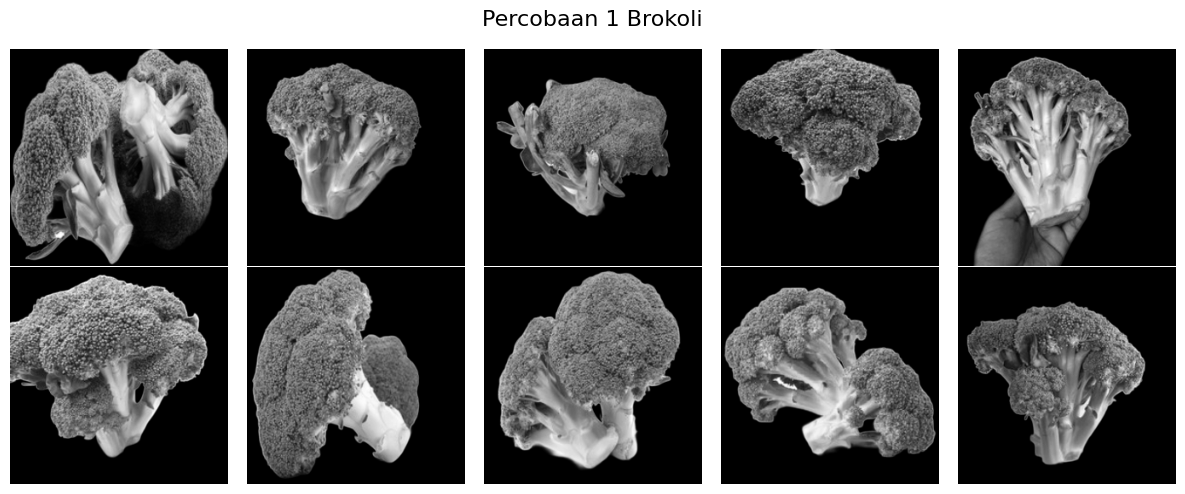

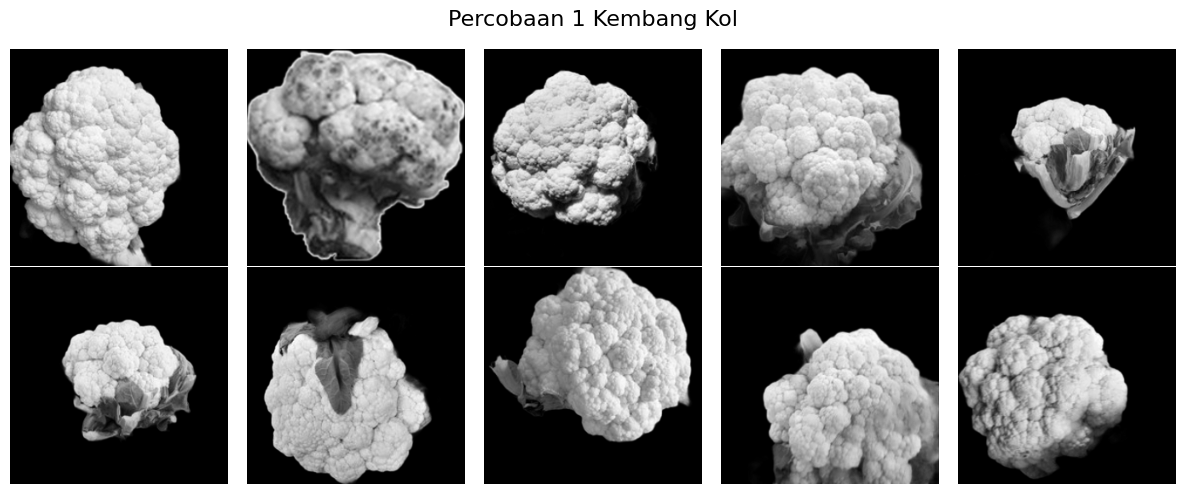

In [11]:
def percobaan1(img):
    img_no_bg = removeBackground(img)
    img_gray = grayscale(img_no_bg)
    img_resize = resize(img_gray, 256, 256)
    return img_resize

dataPreprocessed = [percobaan1(img) for img in data]  

unique_labels = sorted(set(labels))

for label in unique_labels:
    # Ambil semua indeks gambar dari label ini
    idxs = [j for j, l in enumerate(labels) if l == label]
    
    # Buat grid 7x12 (cukup untuk 84 gambar, 7*12 = 84)
    fig, axs = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(f'Percobaan 1 {label}', fontsize=16)
    
    for k in range(10):
        row = k // 5
        col = k % 5
        ax = axs[row][col]
        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  # beri ruang untuk judul
    plt.show()

### Ekstraksi Fitur

In [12]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

Fungsi `glcm(image, derajat)` digunakan untuk membentuk **Gray Level Co-occurrence Matrix (GLCM)** dari citra berdasarkan sudut tertentu, yaitu **0°, 45°, 90°, atau 135°**. Fungsi akan mengonversi sudut yang dipilih ke dalam satuan radian, kemudian menggunakan `graycomatrix()` untuk menghitung matriks ko-okurensi dengan jarak piksel 1. Matriks yang dihasilkan bersifat **simetris** dan **ternormalisasi**, sehingga dapat digunakan untuk ekstraksi fitur tekstur pada tahap analisis citra.


In [13]:
def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Fungsi-fungsi diatas digunakan untuk mengekstraksi **fitur tekstur** dari matriks GLCM. Fitur yang dihitung meliputi **correlation** untuk mengukur hubungan antar piksel, **dissimilarity** untuk mengukur perbedaan tingkat keabuan, **homogeneity** untuk menilai keseragaman tekstur, **contrast** untuk mengukur variasi intensitas, **ASM (Angular Second Moment)** dan **energy** untuk mengukur tingkat keteraturan tekstur, serta **entropy** untuk mengukur tingkat kerandoman atau kompleksitas tekstur pada citra. Fitur-fitur ini kemudian digunakan sebagai masukan dalam proses klasifikasi citra.


Fungsi `ekstrak_fitur_glcm(data, nama_prepro)` dibawah digunakan untuk mengekstraksi **fitur tekstur GLCM** dari setiap citra yang telah melalui tahap pra-pemrosesan. Untuk setiap gambar, fungsi membentuk matriks GLCM pada sudut **0°**, kemudian menghitung beberapa fitur tekstur yaitu **contrast, correlation, energy, homogeneity, dissimilarity, ASM**, dan **entropy**. Seluruh fitur yang diperoleh disimpan dalam sebuah list, lalu dikonversi menjadi **DataFrame Pandas** untuk memudahkan analisis dan pengolahan data. Selain itu, ditambahkan kolom `tahap` yang berisi nama metode pra-pemrosesan yang digunakan. Hasil akhirnya ditampilkan dalam bentuk tabel yang berisi nilai fitur tekstur dari setiap citra.


In [14]:
def ekstrak_fitur_glcm(data, nama_prepro):
    fitur_list = []
    for img in data:
        img_u8 = img.astype(np.uint8)
        m = glcm(img_u8, 0)  # derajat 0
        
        fitur = {
            'contrast': contrast(m),
            'correlation': correlation(m),
            'energy': energy(m),
            'homogeneity': homogenity(m),
            'dissimilarity': dissimilarity(m),
            'ASM': ASM(m),
            'entropy': entropyGlcm(m)
        }
        fitur_list.append(fitur)

    df = pd.DataFrame(fitur_list)
    df['tahap'] = nama_prepro
    return df

df2 = ekstrak_fitur_glcm(dataPreprocessed, 'percobaan1')
display(df2)

,contrast,correlation,energy,homogeneity,dissimilarity,ASM,entropy,tahap
0,329.571063,0.964880,0.249706,0.338273,10.785126,0.062353,7.270364,percobaan1
1,79.509436,0.979398,0.652128,0.693671,3.666422,0.425271,3.467207,percobaan1
2,94.467279,0.976603,0.666860,0.704343,3.882690,0.444702,3.351360,percobaan1
3,125.067065,0.956884,0.619162,0.653821,5.091881,0.383362,3.815265,percobaan1
4,120.199081,0.981359,0.514439,0.584802,5.041605,0.264648,4.775881,percobaan1
...,...,...,...,...,...,...,...,...
195,40.333686,0.994601,0.357198,0.517631,3.329795,0.127590,5.722978,percobaan1
196,107.555561,0.992945,0.530111,0.614182,4.295941,0.281018,4.461483,percobaan1
197,79.080561,0.992878,0.618939,0.675032,3.384023,0.383085,3.729623,percobaan1
198,85.132138,0.994362,0.571911,0.649329,3.440533,0.327082,3.968093,percobaan1


In [15]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

for i in range(len(data)):  
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

Kode diatas digunakan untuk menghitung **fitur tekstur GLCM pada empat orientasi sudut**, yaitu **0°, 45°, 90°, dan 135°**, untuk setiap citra hasil pra-pemrosesan. Pertama, program membentuk matriks GLCM pada masing-masing sudut dan menyimpannya ke dalam variabel `Derajat0`, `Derajat45`, `Derajat90`, dan `Derajat135`. Selanjutnya, dari setiap matriks GLCM tersebut diekstraksi berbagai fitur tekstur seperti **correlation, contrast, dissimilarity, homogeneity, entropy, ASM**, dan **energy**. Nilai fitur dari setiap sudut disimpan ke dalam list terpisah sehingga dapat digunakan untuk analisis karakteristik tekstur citra serta sebagai data masukan pada proses klasifikasi machine learning.


### Hasil Ekstraksi ke CSV

In [16]:
features = []

for i in range(len(dataPreprocessed)):
    fitur = [
        contrast(Derajat0[i]), contrast(Derajat45[i]), contrast(Derajat90[i]), contrast(Derajat135[i]),
        dissimilarity(Derajat0[i]), dissimilarity(Derajat45[i]), dissimilarity(Derajat90[i]), dissimilarity(Derajat135[i]),
        homogenity(Derajat0[i]), homogenity(Derajat45[i]), homogenity(Derajat90[i]), homogenity(Derajat135[i]),
        entropyGlcm(Derajat0[i]), entropyGlcm(Derajat45[i]), entropyGlcm(Derajat90[i]), entropyGlcm(Derajat135[i]),
        ASM(Derajat0[i]), ASM(Derajat45[i]), ASM(Derajat90[i]), ASM(Derajat135[i]),
        energy(Derajat0[i]), energy(Derajat45[i]), energy(Derajat90[i]), energy(Derajat135[i]),
        correlation(Derajat0[i]), correlation(Derajat45[i]), correlation(Derajat90[i]), correlation(Derajat135[i]),
    ]
    features.append(fitur)

# Buat dataframe
columns = [
    "contrast_0", "contrast_45", "contrast_90", "contrast_135",
    "dissimilarity_0", "dissimilarity_45", "dissimilarity_90", "dissimilarity_135",
    "homogeneity_0", "homogeneity_45", "homogeneity_90", "homogeneity_135",
    "entropy_0", "entropy_45", "entropy_90", "entropy_135",
    "ASM_0", "ASM_45", "ASM_90", "ASM_135",
    "energy_0", "energy_45", "energy_90", "energy_135",
    "correlation_0", "correlation_45", "correlation_90", "correlation_135"
]

df_fitur = pd.DataFrame(features, columns=columns)

Kode diatas digunakan untuk menyusun **dataset fitur tekstur GLCM** yang akan digunakan pada tahap klasifikasi. Untuk setiap citra hasil pra-pemrosesan, program mengekstraksi tujuh fitur tekstur yaitu **contrast, dissimilarity, homogeneity, entropy, ASM, energy**, dan **correlation** pada empat sudut orientasi (**0°, 45°, 90°, dan 135°**), sehingga menghasilkan total **28 fitur** untuk setiap citra. Seluruh fitur kemudian disimpan dalam sebuah list dan dikonversi menjadi **DataFrame Pandas (`df_fitur`)** dengan nama kolom yang sesuai, sehingga data siap digunakan untuk proses analisis, seleksi fitur, maupun pelatihan model machine learning.


Kode dibawah digunakan untuk menyusun seluruh hasil **ekstraksi fitur GLCM** ke dalam sebuah **DataFrame Pandas** yang berisi nama file, label kelas, serta nilai fitur tekstur (**contrast, homogeneity, dissimilarity, entropy, ASM, energy,** dan **correlation**) pada sudut **0°, 45°, 90°, dan 135°**. Data tersebut kemudian disimpan ke dalam file CSV bernama `hasil_ekstraksi_percobaan1.csv` menggunakan `to_csv()`. Selanjutnya, file CSV dibaca kembali menggunakan `read_csv()` dan ditampilkan melalui variabel `hasilEkstrak`, sehingga hasil ekstraksi fitur dapat disimpan, diakses, dan dianalisis pada tahap berikutnya.


In [17]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan1.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,0001.jpg,Brokoli,329.571063,448.137870,225.897151,489.470342,0.338273,0.328357,0.358976,0.320800,...,0.062294,0.060307,0.249706,0.244677,0.249587,0.245574,0.964880,0.952186,0.975920,0.947776
1,0002.jpg,Brokoli,79.509436,136.340300,70.260447,115.822745,0.693671,0.683103,0.709016,0.693585,...,0.425221,0.422031,0.652128,0.649462,0.652090,0.649639,0.979398,0.964749,0.981794,0.970054
2,0003.jpg,Brokoli,94.467279,133.577578,87.330331,163.028466,0.704343,0.697089,0.710328,0.694301,...,0.443993,0.439849,0.666860,0.664549,0.666328,0.663211,0.976603,0.966993,0.978371,0.959715
3,0004.jpg,Brokoli,125.067065,229.456471,152.846094,214.840800,0.653821,0.643261,0.654949,0.644132,...,0.382791,0.379665,0.619162,0.616015,0.618701,0.616170,0.956884,0.921058,0.947306,0.926087
4,0005.jpg,Brokoli,120.199081,164.722784,89.260922,194.577455,0.584802,0.573872,0.619790,0.576327,...,0.266382,0.263154,0.514439,0.511984,0.516122,0.512986,0.981359,0.974496,0.986162,0.969873
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0096.jpg,Kembang Kol,40.333686,107.041338,80.611918,123.952157,0.517631,0.472946,0.491275,0.462874,...,0.124676,0.123286,0.357198,0.351425,0.353095,0.351121,0.994601,0.985680,0.989214,0.983418
196,0097.jpg,Kembang Kol,107.555561,192.743022,112.427114,208.293626,0.614182,0.599331,0.627330,0.593711,...,0.280376,0.276732,0.530111,0.525973,0.529505,0.526053,0.992945,0.987372,0.992625,0.986353
197,0098.jpg,Kembang Kol,79.080561,128.514095,72.376409,144.459839,0.675032,0.669568,0.683633,0.658720,...,0.381849,0.379644,0.618939,0.615980,0.617939,0.616153,0.992878,0.988447,0.993481,0.987013
198,0099.jpg,Kembang Kol,85.132138,149.724875,86.496599,158.440108,0.649329,0.636454,0.653697,0.627576,...,0.327035,0.323843,0.571911,0.568668,0.571870,0.569072,0.994362,0.990096,0.994271,0.989520


## Feature Selection

### Correlation

Berdasarkan hasil pengujian korelasi terhadap 28 fitur GLCM awal, ditemukan tingkat multikolinearitas yang sangat tinggi antar-fitur properti tekstur. Dengan menerapkan threshold korelasi sebesar 0.85, sistem berhasil mereduksi dimensi data secara signifikan hingga menyisakan 3 fitur independen terbaik, yaitu Contrast0, Homogeneity0, Correlation0. Meskipun eliminasi data redundan ini menyebabkan penurunan akurasi model Random Forest dari 85% menjadi 82.50%, penggunaan 3 fitur hasil seleksi ini dinilai jauh lebih efisien dalam memangkas waktu komputasi training model secara masif dengan tetap mempertahankan performa klasifikasi objek brokoli dan kembang kol yang kuat.

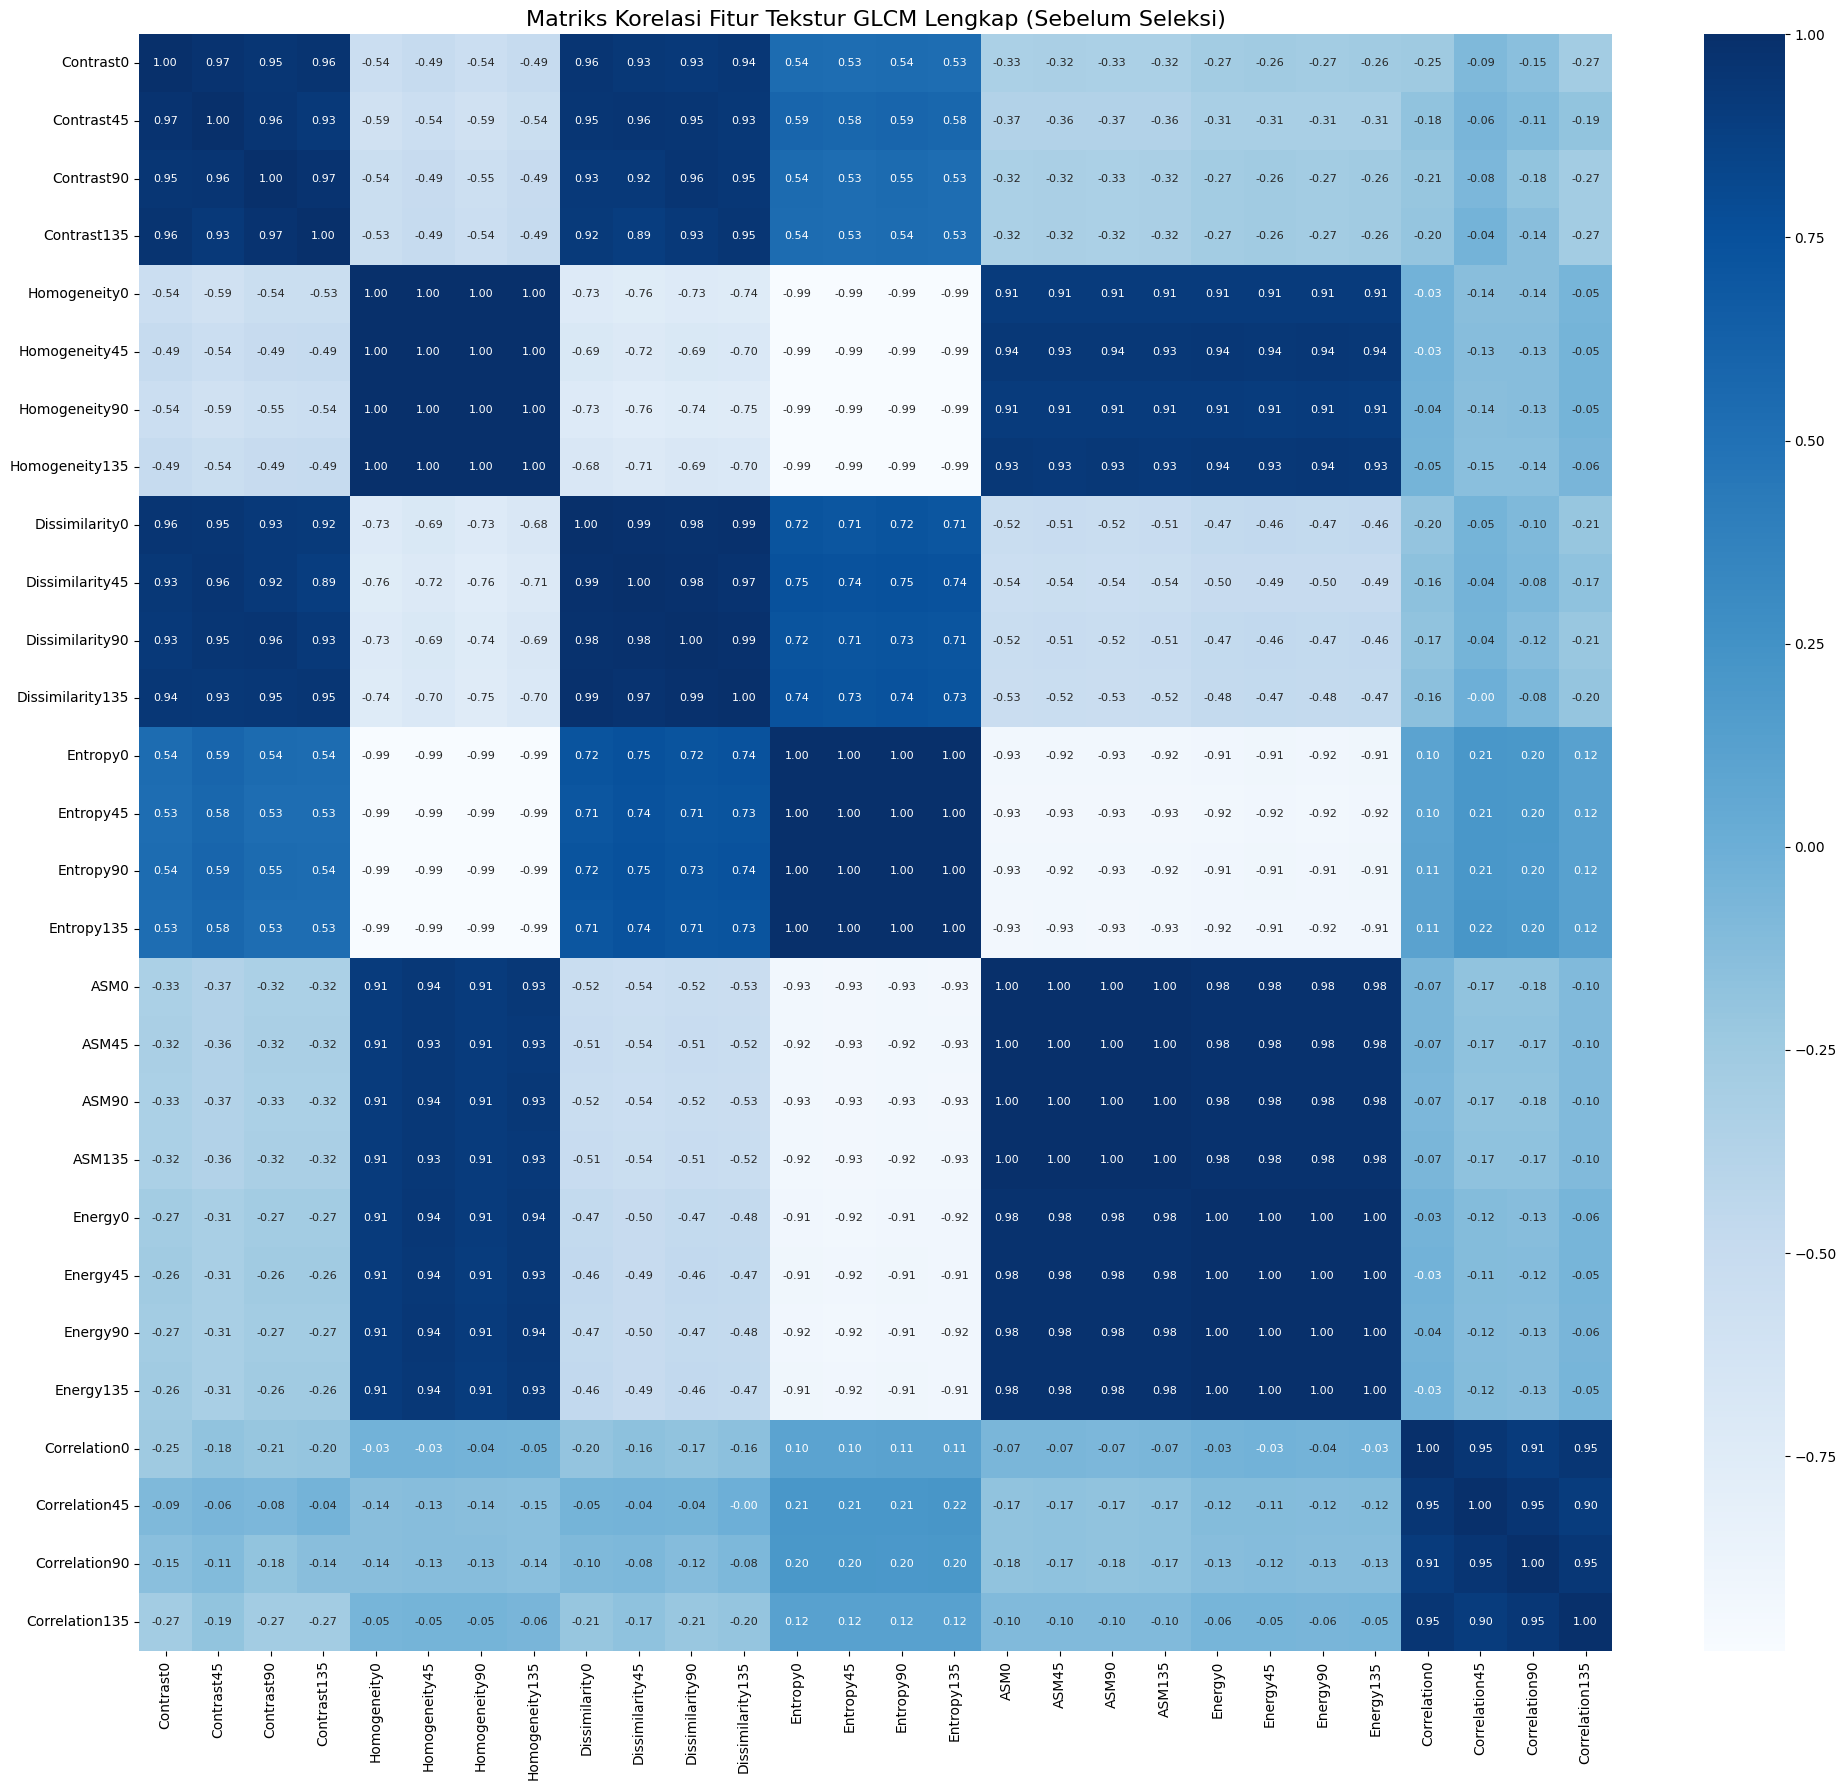

--- HASIL SELEKSI FITUR ---
Jumlah fitur awal : 28 fitur
Jumlah fitur setelah disaring (Korelasi < 0.85) : 3 fitur
Fitur yang terpilih: ['Contrast0', 'Homogeneity0', 'Correlation0']

Akurasi SEBELUM Seleksi Korelasi (28 fitur): 85.00%
Akurasi SETELAH Seleksi Korelasi (3 fitur) : 82.50%


In [18]:
correlation = hasilEkstrak.drop(columns=['Label', 'Filename']).corr()

plt.figure(figsize=(20, 18))
sns.heatmap(correlation, annot=True, cmap='Blues', fmt=".2f", cbar=True, annot_kws={"size": 8})
plt.title("Matriks Korelasi Fitur Tekstur GLCM Lengkap (Sebelum Seleksi)", fontsize=16)
plt.tight_layout()
plt.show()

threshold = 0.85 
columns_mask = np.full((correlation.shape[0],), True, dtype=bool)

for i in range(correlation.shape[0]):
    for j in range(i+1, correlation.shape[0]):
        if abs(correlation.iloc[i, j]) >= threshold:
            if columns_mask[j]:
                columns_mask[j] = False

select = hasilEkstrak.drop(columns=['Label', 'Filename']).columns[columns_mask]

x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"--- HASIL SELEKSI FITUR ---")
print(f"Jumlah fitur awal : {correlation.shape[0]} fitur")
print(f"Jumlah fitur setelah disaring (Korelasi < {threshold}) : {x_new.shape[1]} fitur")
print(f"Fitur yang terpilih: {list(select)}\n")

# Split data menggunakan fitur awal vs fitur baru
X_train_old, X_test_old, y_train, y_test = train_test_split(
    hasilEkstrak.drop(columns=['Label', 'Filename']), y, test_size=0.2, random_state=42
)
X_train_new, X_test_new, _, _ = train_test_split(x_new, y, test_size=0.2, random_state=42)

# Model dengan fitur awal
model_old = RandomForestClassifier(random_state=42)
model_old.fit(X_train_old, y_train)
acc_old = accuracy_score(y_test, model_old.predict(X_test_old))

# Model dengan fitur hasil seleksi
model_new = RandomForestClassifier(random_state=42)
model_new.fit(X_train_new, y_train)
acc_new = accuracy_score(y_test, model_new.predict(X_test_new))

print("="*60)
print(f"Akurasi SEBELUM Seleksi Korelasi ({correlation.shape[0]} fitur): {acc_old * 100:.2f}%")
print(f"Akurasi SETELAH Seleksi Korelasi ({x_new.shape[1]} fitur) : {acc_new * 100:.2f}%")
print("="*60)

### Spliting Data

Kode dibawah digunakan untuk membagi dataset menjadi **data latih (training)** dan **data uji (testing)** menggunakan fungsi `train_test_split()`. Pada contoh ini, nilai `test_size=0.2` menunjukkan bahwa **20% data digunakan untuk pengujian** dan **80% sisanya digunakan untuk pelatihan model**, sedangkan `random_state=42` digunakan agar hasil pembagian data tetap konsisten setiap kali program dijalankan. Setelah proses pembagian selesai, program menampilkan ukuran (shape) dari data dan label pada masing-masing subset untuk memastikan bahwa pembagian data telah dilakukan dengan benar.


In [19]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 3)
(40, 3)
(160,)
(40,)


### Feature Normalization

In [20]:
# normalisasi mean std (Standardization / Z-score normalization)
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

Kode diatas digunakan untuk normalisasi mean-std (Standardisasi atau Z-score normalization) pada fitur-fitur training (X_train) dan testing set (X_test). Normalisasi ini dilakukan dengan mengurangi setiap nilai fitur dengan rata-rata training set (X_train.mean()) dan membaginya dengan standar deviasi training set (X_train.std()). Pentingnya metode ini adalah bahwa rata-rata dan standar deviasi hanya dihitung dari X_train dan kemudian diterapkan ke X_test, sebuah praktik yang mencegah data leakage dan memastikan integritas pengujian model.

## Modeling

### Define Model

In [21]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=4, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

Kode diatas digunakan untuk menyiapkan proses **evaluasi dan klasifikasi data**. Fungsi `generateClassificationReport()` berfungsi menampilkan hasil evaluasi model berupa **classification report**, **confusion matrix**, dan **akurasi** untuk membandingkan label sebenarnya dengan hasil prediksi model. Selain itu, kode juga mendefinisikan tiga algoritma machine learning yang akan digunakan, yaitu **Random Forest** dengan 4 pohon keputusan (`n_estimators=4`), **Support Vector Machine (SVM)** dengan kernel **RBF**, dan **K-Nearest Neighbor (KNN)** dengan jumlah tetangga terdekat sebanyak 5 (`n_neighbors=5`). Ketiga model ini kemudian dapat dilatih dan dibandingkan performanya dalam mengklasifikasikan citra Brokoli dan Kembang Kol.


### Train Random Forest Classifier

Kode dibawah digunakan untuk **melatih dan mengevaluasi model Random Forest**. Model terlebih dahulu dilatih menggunakan data latih (`X_train` dan `y_train`) melalui fungsi `fit()`. Setelah proses pelatihan selesai, model digunakan untuk melakukan prediksi pada data latih dan data uji menggunakan fungsi `predict()`. Hasil prediksi kemudian dievaluasi menggunakan fungsi `generateClassificationReport()`, yang menampilkan **classification report**, **confusion matrix**, dan **akurasi**. Evaluasi pada data latih bertujuan untuk melihat kemampuan model dalam mempelajari data, sedangkan evaluasi pada data uji digunakan untuk mengukur kemampuan model dalam mengklasifikasikan data baru yang belum pernah dilihat sebelumnya.

Model mencatatkan nilai akurasi sebesar 96.25% pada training set dan sebesar 85.00% pada testing set. Berdasarkan analisis matriks konfusi pada data testing, dari total 40 sampel uji, model mampu mengklasifikasikan 20 data brokoli dan 14 data kembang kol secara akurat, dengan margin kesalahan sebanyak 6 citra. Keberhasilan pencapaian akurasi testing hingga 85.00% ini membuktikan bahwa tahap pengisolasian objek melalui segmentasi remove background efektif menghilangkan noise latar belakang citra yang tidak relevan.

In [22]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

     Brokoli       0.94      0.99      0.96        79
 Kembang Kol       0.99      0.94      0.96        81

    accuracy                           0.96       160
   macro avg       0.96      0.96      0.96       160
weighted avg       0.96      0.96      0.96       160

[[78  1]
 [ 5 76]]
Accuracy: 0.9625

------Testing Set------
              precision    recall  f1-score   support

     Brokoli       0.80      0.95      0.87        21
 Kembang Kol       0.93      0.74      0.82        19

    accuracy                           0.85        40
   macro avg       0.87      0.84      0.85        40
weighted avg       0.86      0.85      0.85        40

[[20  1]
 [ 5 14]]
Accuracy: 0.85


### Train SVM Classifier

Kode dibawah digunakan untuk **melatih dan mengevaluasi model Support Vector Machine (SVM)** menggunakan data latih (`X_train` dan `y_train`). Setelah model dilatih dengan fungsi `fit()`, dilakukan prediksi pada data latih dan data uji menggunakan fungsi `predict()`. Hasil prediksi kemudian dievaluasi melalui fungsi `generateClassificationReport()` yang menampilkan **classification report**, **confusion matrix**, dan **akurasi**. Evaluasi pada data latih digunakan untuk menilai kemampuan model dalam mempelajari pola data, sedangkan evaluasi pada data uji digunakan untuk mengukur kemampuan generalisasi model terhadap data yang belum pernah dipelajari sebelumnya.

model menunjukkan performa yang stabil dengan tingkat akurasi pada training set sebesar 92.50% dan pada testing set sebesar 82.50%. Melalui analisis matriks konfusi pada data testing, dari total 40 sampel uji, model mampu mengenali 19 citra brokoli dan 14 citra kembang kol secara tepat. Rendahnya selisih akurasi antara data training dan testing (10.00%) mengindikasikan bahwa model tidak mengalami overfitting dan memiliki kemampuan generalisasi yang baik. Keberhasilan klasifikasi ini didukung oleh tahapan remove background yang berhasil mengeliminasi noise spasial pada latar belakang objek. Namun, adanya kemiripan sebaran nilai intensitas piksel abu-abu (grayscale) antara tekstur kembang kol yang padat dengan karakteristik permukaan brokoli menyebabkan beberapa titik support vectors milik kembang kol melintasi batas keputusan (hyperplane), sehingga menghasilkan error berupa 5 citra kembang kol yang terprediksi sebagai brokoli.

In [23]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     Brokoli       0.91      0.94      0.93        79
 Kembang Kol       0.94      0.91      0.93        81

    accuracy                           0.93       160
   macro avg       0.93      0.93      0.93       160
weighted avg       0.93      0.93      0.93       160

[[74  5]
 [ 7 74]]
Accuracy: 0.925

------Testing Set------
              precision    recall  f1-score   support

     Brokoli       0.79      0.90      0.84        21
 Kembang Kol       0.88      0.74      0.80        19

    accuracy                           0.82        40
   macro avg       0.83      0.82      0.82        40
weighted avg       0.83      0.82      0.82        40

[[19  2]
 [ 5 14]]
Accuracy: 0.825


### Train KNN Classifier

Kode dibawah digunakan untuk **melatih dan mengevaluasi model K-Nearest Neighbor (KNN)** menggunakan data latih (`X_train` dan `y_train`). Setelah model dilatih dengan fungsi `fit()`, dilakukan prediksi terhadap data latih dan data uji menggunakan fungsi `predict()`. Hasil prediksi kemudian dievaluasi melalui fungsi `generateClassificationReport()` yang menampilkan **classification report**, **confusion matrix**, dan **akurasi**. Evaluasi pada data latih menunjukkan kemampuan model dalam mengenali pola pada data pelatihan, sedangkan evaluasi pada data uji digunakan untuk mengukur kinerja model dalam mengklasifikasikan data baru yang belum pernah digunakan selama proses pelatihan.

model menghasilkan tingkat akurasi pada training set sebesar 93.125% dan pada testing set sebesar 77.50%. Hasil matriks konfusi menunjukkan bahwa dari 40 sampel data uji, model mampu mengklasifikasikan 17 citra brokoli dan 14 citra kembang kol secara tepat, sementara 9 citra lainnya mengalami misklasifikasi. Dibandingkan dengan algoritma pengklasifikasi lainnya pada percobaan yang sama, KNN mencatatkan performa akurasi testing terendah. Hal ini dikarenakan KNN bekerja murni berdasarkan perhitungan jarak kedekatan nilai piksel (Euclidean Distance) di dalam ruang dimensi tinggi berukuran 256 x 256 piksel tanpa adanya ekstraksi fitur tekstur sekunder. Meskipun tahapan remove background telah berhasil menyamakan nilai latar belakang objek menjadi konstan, hilangnya informasi warna akibat proses grayscaling menyebabkan representasi jarak vektor antara tekstur permukaan brokoli dan kembang kol menjadi sangat berhimpitan, terutama pada kondisi citra yang memiliki variasi intensitas pencahayaan (brightness) yang serupa, sehingga memicu tingginya tingkat kesalahan voting tetangga terdekat pada model KNN.

In [24]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     Brokoli       0.91      0.95      0.93        79
 Kembang Kol       0.95      0.91      0.93        81

    accuracy                           0.93       160
   macro avg       0.93      0.93      0.93       160
weighted avg       0.93      0.93      0.93       160

[[75  4]
 [ 7 74]]
Accuracy: 0.93125

------Testing Set------
              precision    recall  f1-score   support

     Brokoli       0.77      0.81      0.79        21
 Kembang Kol       0.78      0.74      0.76        19

    accuracy                           0.78        40
   macro avg       0.78      0.77      0.77        40
weighted avg       0.78      0.78      0.77        40

[[17  4]
 [ 5 14]]
Accuracy: 0.775


### Evaluasi Dengan Confussion Matrix

Kode dibawah digunakan untuk memvisualisasikan **confusion matrix** dari hasil klasifikasi. Fungsi `plot_confusion_matrix()` terlebih dahulu menghitung confusion matrix berdasarkan label sebenarnya (`y_true`) dan hasil prediksi (`y_pred`), kemudian menampilkannya dalam bentuk grafik menggunakan `ConfusionMatrixDisplay`. Selanjutnya, fungsi tersebut digunakan untuk menampilkan confusion matrix dari tiga model yang telah dilatih, yaitu **Random Forest**, **SVM**, dan **KNN**, sehingga memudahkan analisis jumlah prediksi yang benar maupun salah pada masing-masing model klasifikasi.


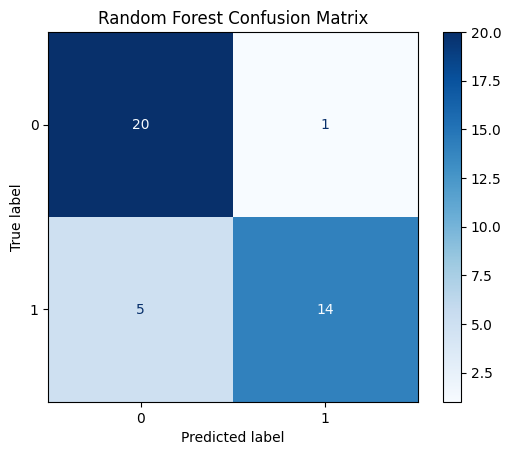

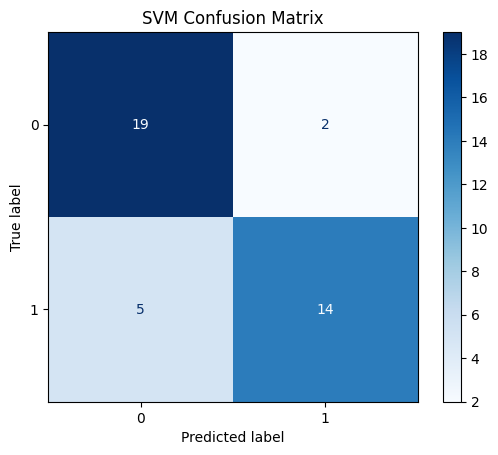

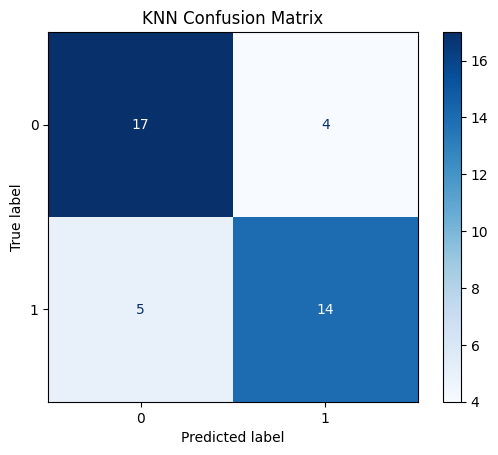

In [25]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")